# AI vs Human Text Analysis: N-gram Distribution Study

This notebook implements an additional analysis for my IS:

**N-gram Distribution Analysis**

Goal:
To analyze how phrase-level patterns (n-grams) differ between human-written and AI-generated text.

We focus on:
- Top n-grams
- Frequency distributions
- Repetition patterns
- Lexical diversity
- Entropy of n-gram usage

Dataset:
Balanced 10K dataset used across all pipelines.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import math

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

In [4]:
file_path = r"D:\IS\IS Final\Data\IS_Dataset_AI_vs_Human_10K.xlsx"
df = pd.read_excel(file_path)

df["Text"] = df["Text"].astype(str)

ai_texts = df[df.Label == 1]["Text"]
human_texts = df[df.Label == 0]["Text"]

print("Dataset loaded:", df.shape)

Dataset loaded: (10000, 2)


## N-gram Extraction

We extract unigram, bigram, and trigram representations using CountVectorizer.

In [5]:
def get_top_ngrams(corpus, ngram_range=(2,2), top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = vec.fit_transform(corpus)
    
    sums = np.array(X.sum(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    
    data = list(zip(terms, sums))
    sorted_data = sorted(data, key=lambda x: x[1], reverse=True)
    
    return sorted_data[:top_n]

In [ ]:
# Top Bigrams
top_ai_bigrams = get_top_ngrams(ai_texts, (2,2), 20)
top_human_bigrams = get_top_ngrams(human_texts, (2,2), 20)

ai_df = pd.DataFrame(top_ai_bigrams, columns=["ngram", "freq"])
ai_df["label"] = "AI"

human_df = pd.DataFrame(top_human_bigrams, columns=["ngram", "freq"])
human_df["label"] = "Human"

combined_df = pd.concat([ai_df, human_df])

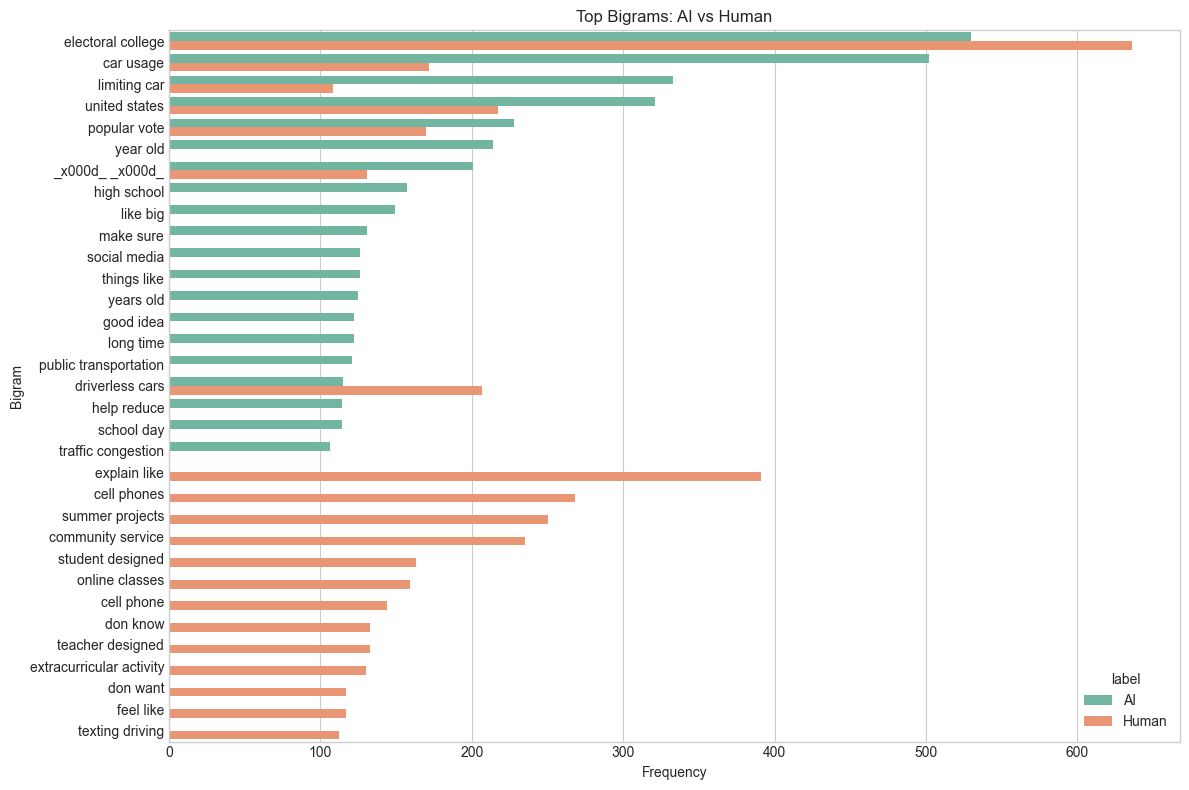

In [7]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=combined_df,
    y="ngram",
    x="freq",
    hue="label"
)

plt.title("Top Bigrams: AI vs Human")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

## N-gram Diversity

We measure how diverse the n-gram usage is by counting unique n-grams.

In [8]:
def ngram_diversity(corpus, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = vec.fit_transform(corpus)
    
    total = X.sum()
    unique = len(vec.get_feature_names_out())
    
    return unique / total

ai_div = ngram_diversity(ai_texts)
human_div = ngram_diversity(human_texts)

print("AI Diversity:", ai_div)
print("Human Diversity:", human_div)

AI Diversity: 0.7063682068470194
Human Diversity: 0.7210242090242582


## Repetition Analysis

We analyze how frequently n-grams repeat across texts.

In [9]:
def repetition_score(corpus, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = vec.fit_transform(corpus)
    
    counts = np.array(X.sum(axis=0)).flatten()
    
    return np.mean(counts)

ai_rep = repetition_score(ai_texts)
human_rep = repetition_score(human_texts)

print("AI Repetition:", ai_rep)
print("Human Repetition:", human_rep)

AI Repetition: 1.4156922555499067
Human Repetition: 1.3869159835191551


## Entropy of N-gram Distribution

Entropy measures how unpredictable or diverse the distribution is.

In [10]:
def entropy(corpus, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = vec.fit_transform(corpus)
    
    freqs = np.array(X.sum(axis=0)).flatten()
    probs = freqs / freqs.sum()
    
    return -np.sum(probs * np.log2(probs + 1e-10))

ai_entropy = entropy(ai_texts)
human_entropy = entropy(human_texts)

print("AI Entropy:", ai_entropy)
print("Human Entropy:", human_entropy)

AI Entropy: 17.222461576037627
Human Entropy: 17.32097322328533


## Frequency Distribution Visualization

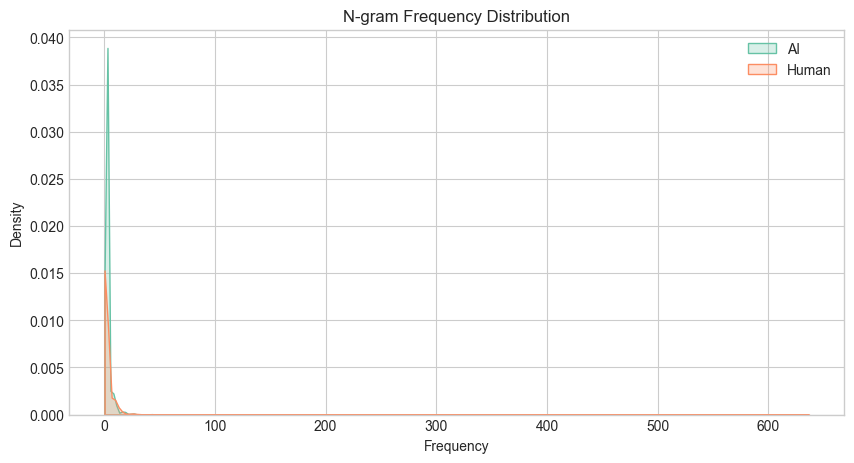

In [11]:
def frequency_distribution(corpus, ngram_range=(2,2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english")
    X = vec.fit_transform(corpus)
    
    freqs = np.array(X.sum(axis=0)).flatten()
    return freqs

ai_freq = frequency_distribution(ai_texts)
human_freq = frequency_distribution(human_texts)

plt.figure(figsize=(10,5))

sns.kdeplot(ai_freq, label="AI", fill=True)
sns.kdeplot(human_freq, label="Human", fill=True)

plt.title("N-gram Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Density")
plt.legend()
plt.show()

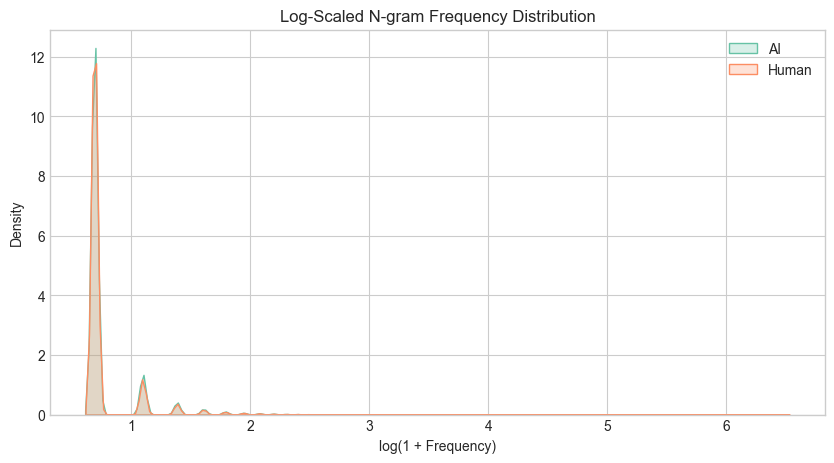

In [12]:
plt.figure(figsize=(10,5))

sns.kdeplot(np.log1p(ai_freq), label="AI", fill=True)
sns.kdeplot(np.log1p(human_freq), label="Human", fill=True)

plt.title("Log-Scaled N-gram Frequency Distribution")
plt.xlabel("log(1 + Frequency)")
plt.ylabel("Density")
plt.legend()
plt.show()

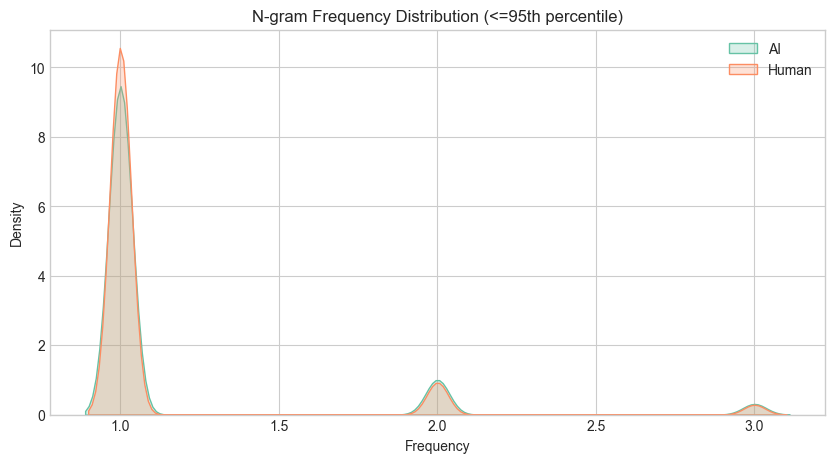

In [13]:
cutoff = np.percentile(np.concatenate([ai_freq, human_freq]), 95)

ai_trim = ai_freq[ai_freq <= cutoff]
human_trim = human_freq[human_freq <= cutoff]

plt.figure(figsize=(10,5))

sns.kdeplot(ai_trim, label="AI", fill=True)
sns.kdeplot(human_trim, label="Human", fill=True)

plt.title("N-gram Frequency Distribution (<=95th percentile)")
plt.xlabel("Frequency")
plt.ylabel("Density")
plt.legend()
plt.show()

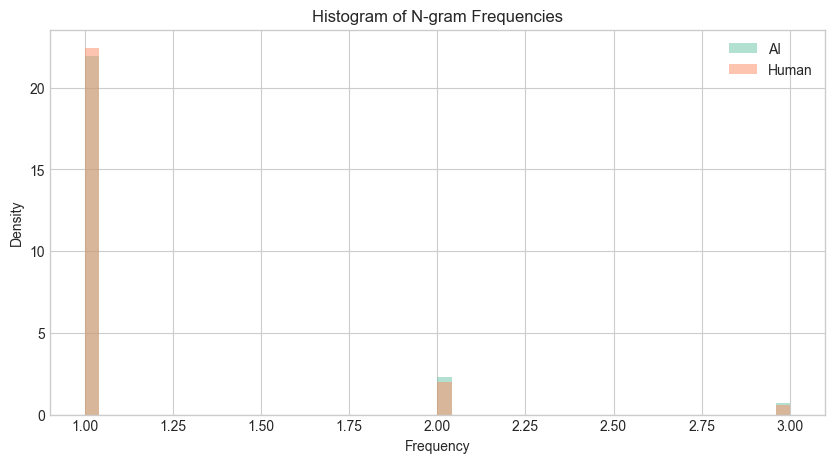

In [14]:
plt.figure(figsize=(10,5))

plt.hist(ai_trim, bins=50, alpha=0.5, label="AI", density=True)
plt.hist(human_trim, bins=50, alpha=0.5, label="Human", density=True)

plt.title("Histogram of N-gram Frequencies")
plt.xlabel("Frequency")
plt.ylabel("Density")
plt.legend()
plt.show()

In [15]:
def summary_stats(arr):
    return {
        "Mean": np.mean(arr),
        "Median": np.median(arr),
        "Std": np.std(arr),
        "Q1": np.percentile(arr, 25),
        "Q3": np.percentile(arr, 75),
        "Max": np.max(arr)
    }

summary_df = pd.DataFrame({
    "AI": summary_stats(ai_freq),
    "Human": summary_stats(human_freq)
}).T

summary_df

,Mean,Median,Std,Q1,Q3,Max
AI,1.415692,1.0,3.030443,1.0,1.0,530.0
Human,1.386916,1.0,2.978745,1.0,1.0,636.0
